In [1]:
import pandas as pd
import numpy as np
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt


from matplotlib.ticker import MultipleLocator

font = {'family':'helvetica neue',
            'color':  'black',
            'weight': 'bold',
            'size': 12
            }
rs={'family':'helvetica neue',
    'size':14
   }

/Users/jesucastin/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
#PRE

WT_PRE_NC=pd.read_csv('../../../data/dihedrals/net_communication/preLC3B_OPLS/NET_COMM/preLC3B_OPLS_net_comm.csv',
                    index_col=0)
WT_PRE_full_np=WT_PRE_NC.to_numpy()+WT_PRE_NC.transpose().to_numpy()
WT_PRE_full_np=WT_PRE_full_np/np.max(WT_PRE_full_np)
WT_PRE_full_df=pd.DataFrame(WT_PRE_full_np)
WT_PRE_full_df

,0,1,2,3,4,5,6,7,8,9,...,115,116,117,118,119,120,121,122,123,124
0,0.000000,0.037449,0.054180,0.088415,0.072415,0.063390,0.047769,0.050867,0.064940,0.068183,...,0.084147,0.090716,0.105577,0.077425,0.058145,0.044077,0.043268,0.061654,0.085468,0.100003
1,0.037449,0.000000,0.063448,0.114216,0.107138,0.088392,0.057381,0.056279,0.090880,0.087667,...,0.118159,0.156247,0.155636,0.129314,0.131024,0.121750,0.173759,0.190056,0.197002,0.186936
2,0.054180,0.063448,0.000000,0.129456,0.126549,0.112462,0.075176,0.067404,0.113768,0.106728,...,0.135812,0.171661,0.175591,0.142269,0.165032,0.170706,0.228152,0.234700,0.226459,0.211996
3,0.088415,0.114216,0.129456,0.000000,0.165850,0.155395,0.112088,0.096856,0.143609,0.147702,...,0.158490,0.210468,0.210443,0.162286,0.154421,0.172407,0.234447,0.230663,0.223271,0.201924
4,0.072415,0.107138,0.126549,0.165850,0.000000,0.152301,0.109747,0.109617,0.150974,0.147346,...,0.148697,0.191222,0.188226,0.147293,0.122380,0.137013,0.166729,0.177247,0.181871,0.194105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,0.044077,0.121750,0.170706,0.172407,0.137013,0.113273,0.092602,0.085248,0.107570,0.112405,...,0.239715,0.316188,0.322249,0.280053,0.288048,0.000000,0.304865,0.303082,0.348379,0.362418
121,0.043268,0.173759,0.228152,0.234447,0.166729,0.143261,0.117633,0.093747,0.125556,0.144922,...,0.332419,0.392667,0.442880,0.351954,0.335819,0.304865,0.000000,0.347911,0.381566,0.393636
122,0.061654,0.190056,0.234700,0.230663,0.177247,0.155774,0.122113,0.107756,0.145233,0.155768,...,0.285660,0.383456,0.387637,0.332523,0.300633,0.303082,0.347911,0.000000,0.407782,0.422324
123,0.085468,0.197002,0.226459,0.223271,0.181871,0.180098,0.137167,0.133326,0.166566,0.173751,...,0.294835,0.431048,0.403556,0.363579,0.271912,0.348379,0.381566,0.407782,0.000000,0.362320


In [3]:
#UNB

WT_UNB_NC=pd.read_csv('../../../data/dihedrals/net_communication/LC3B_II_ER_protein/NET_COMM/LC3B_II_ER_protein_net_comm.csv',
                    index_col=0)
WT_UNB_full_np=WT_UNB_NC.to_numpy()+WT_UNB_NC.transpose().to_numpy()
WT_UNB_full_np=WT_UNB_full_np/np.max(WT_UNB_full_np)
WT_UNB_full_df=pd.DataFrame(WT_UNB_full_np)
WT_UNB_full_df

,0,1,2,3,4,5,6,7,8,9,...,109,110,111,112,113,114,115,116,117,118
0,0.000000,0.252592,0.236815,0.243170,0.194645,0.137060,0.109878,0.103053,0.137060,0.132555,...,0.072376,0.084087,0.099944,0.123600,0.158976,0.144991,0.202793,0.172997,0.212545,0.116410
1,0.252592,0.000000,0.331883,0.371719,0.327705,0.239599,0.170917,0.151606,0.239599,0.230593,...,0.076259,0.102260,0.137554,0.172455,0.245411,0.230283,0.382987,0.307054,0.408454,0.168614
2,0.236815,0.331883,0.000000,0.485563,0.494991,0.372946,0.271516,0.242909,0.372946,0.357831,...,0.090165,0.131910,0.211004,0.225733,0.272285,0.264781,0.343412,0.275390,0.349530,0.161337
3,0.243170,0.371719,0.485563,0.000000,0.612863,0.460740,0.333997,0.298732,0.460740,0.441635,...,0.101943,0.148564,0.242435,0.270025,0.333912,0.330500,0.426936,0.326236,0.425929,0.187439
4,0.194645,0.327705,0.494991,0.612863,0.000000,0.413453,0.323764,0.313370,0.413453,0.428419,...,0.118854,0.150255,0.247224,0.258760,0.321910,0.306356,0.331584,0.257482,0.313988,0.158640
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114,0.144991,0.230283,0.264781,0.330500,0.306356,0.197130,0.160809,0.160752,0.197130,0.194627,...,0.093097,0.165326,0.278677,0.275857,0.316883,0.000000,0.272667,0.232627,0.244741,0.156928
115,0.202793,0.382987,0.343412,0.426936,0.331584,0.183662,0.148995,0.145026,0.183662,0.181840,...,0.084006,0.134734,0.212131,0.226191,0.284492,0.272667,0.000000,0.274448,0.288977,0.193646
116,0.172997,0.307054,0.275390,0.326236,0.257482,0.149610,0.118211,0.115851,0.149610,0.137047,...,0.082830,0.117481,0.177624,0.178724,0.253477,0.232627,0.274448,0.000000,0.256976,0.180185
117,0.212545,0.408454,0.349530,0.425929,0.313988,0.172583,0.129076,0.128783,0.172583,0.160281,...,0.087614,0.106858,0.146539,0.169073,0.257896,0.244741,0.288977,0.256976,0.000000,0.178945


In [4]:
#BND

WT_BND_NC=pd.read_csv('../../../data/dihedrals/net_communication/LC3B_P62_INCLUDED/NET_COMM/LC3B_P62_INCLUDED_net_comm.csv',
                    index_col=0)
WT_BND_full_np=WT_BND_NC.to_numpy()+WT_BND_NC.transpose().to_numpy()
WT_BND_full_np=WT_BND_full_np/np.max(WT_BND_full_np)
WT_BND_full_df=pd.DataFrame(WT_BND_full_np)
WT_BND_full_df

,0,1,2,3,4,5,6,7,8,9,...,116,117,118,119,120,121,122,123,124,125
0,0.000000,0.158475,0.187878,0.215393,0.189740,0.147977,0.109910,0.092542,0.139338,0.134938,...,0.122795,0.166033,0.142562,0.169678,0.147780,0.084179,0.095008,0.115733,0.100031,0.122067
1,0.158475,0.000000,0.292071,0.352111,0.312922,0.267619,0.152324,0.100782,0.252011,0.222836,...,0.194971,0.231572,0.182510,0.245116,0.257317,0.144269,0.150966,0.122517,0.141038,0.170365
2,0.187878,0.292071,0.000000,0.420160,0.397487,0.317097,0.204498,0.129782,0.293051,0.276119,...,0.221820,0.219749,0.157261,0.297826,0.331283,0.183336,0.204061,0.165285,0.173296,0.217030
3,0.215393,0.352111,0.420160,0.000000,0.497278,0.385152,0.249864,0.150789,0.357214,0.341396,...,0.262357,0.256754,0.180209,0.388046,0.428525,0.229958,0.251662,0.195926,0.206330,0.255326
4,0.189740,0.312922,0.397487,0.497278,0.000000,0.382868,0.294731,0.222286,0.383223,0.410980,...,0.216004,0.233722,0.182767,0.455535,0.421177,0.250730,0.295344,0.280751,0.250448,0.301836
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,0.084179,0.144269,0.183336,0.229958,0.250730,0.207038,0.205711,0.116396,0.210269,0.250780,...,0.107351,0.154339,0.125668,0.468981,0.431370,0.000000,0.238635,0.223386,0.184059,0.192707
122,0.095008,0.150966,0.204061,0.251662,0.295344,0.255027,0.242021,0.153033,0.248880,0.302369,...,0.105210,0.145481,0.134665,0.513108,0.389491,0.238635,0.000000,0.286812,0.242584,0.255293
123,0.115733,0.122517,0.165285,0.195926,0.280751,0.270463,0.260306,0.172948,0.261518,0.316400,...,0.092637,0.156168,0.139164,0.476879,0.359442,0.223386,0.286812,0.000000,0.277468,0.313348
124,0.100031,0.141038,0.173296,0.206330,0.250448,0.218230,0.200303,0.143481,0.215933,0.244180,...,0.093637,0.122207,0.112027,0.343632,0.260670,0.184059,0.242584,0.277468,0.000000,0.266750


In [5]:
glob_comm_pre=[i for i in WT_PRE_full_df.sum(axis=0)]
glob_comm_unb=[i for i in WT_UNB_full_df.sum(axis=0)]
glob_comm_bnd=[i for i in WT_BND_full_df.sum(axis=0)]
glob_comm_bnd_lc3b=glob_comm_bnd[:119]
glob_comm_bnd_p62=glob_comm_bnd[119:]

In [6]:
glob_comm_df=pd.DataFrame()
glob_comm_df['Residues']=[i for i in range(1,120)]
glob_comm_df['PRE']=glob_comm_pre[:119]
glob_comm_df['UNB']=glob_comm_unb
glob_comm_df['BND']=glob_comm_bnd_lc3b
glob_comm_df

,Residues,PRE,UNB,BND
0,1,7.448003,12.975242,13.755193
1,2,10.665561,17.812994,18.939279
2,3,12.183976,20.604743,21.953052
3,4,14.104262,23.822566,25.840430
4,5,13.057484,23.117511,25.798132
...,...,...,...,...
114,115,8.236571,19.784540,18.481282
115,116,17.193664,18.609025,17.057277
116,117,22.630552,16.706142,15.750763
117,118,21.940260,16.937828,17.716486


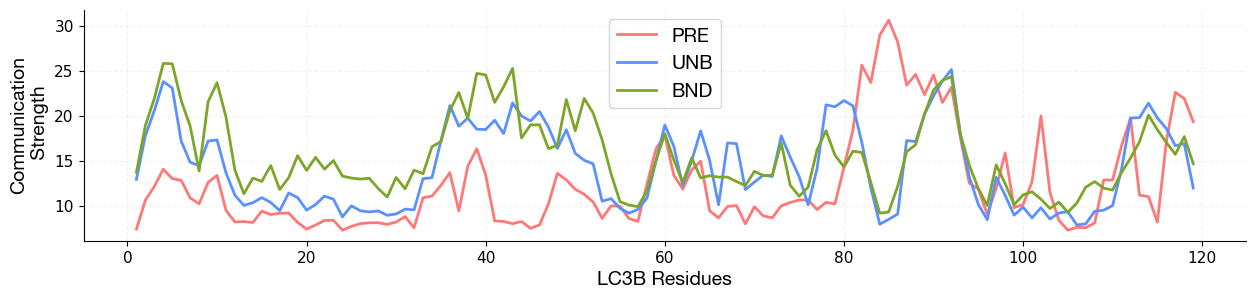

In [7]:
font = {'family':'helvetica neue',
        'color':  'black',
        'weight': 'bold',
        'size': 14
        }
rs={'family':'helvetica neue',
    'size':14
   }

fig, ax = plt.subplots(figsize=(15, 3))


ax.plot(glob_comm_df["Residues"], glob_comm_df["PRE"],color="#FF7878",lw=2,label="PRE")
#ax.scatter()
ax.plot(glob_comm_df["Residues"], glob_comm_df["UNB"],color="#5A91FF",lw=2,label="UNB")
ax.plot(glob_comm_df["Residues"], glob_comm_df["BND"],color="#7DA629",lw=2,label="BND")


ax.tick_params(labelsize=11)
ax.set_xlabel('LC3B Residues', fontdict=font)  # Setting font for x-axis label
ax.set_ylabel('Communication\n Strength', fontdict=font)  # Setting font for y-axis label

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.1)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.1)

# ax.tick_params(labelsize=10)
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

# ax.set_ylim(0,1)
plt.legend(prop=rs)
plt.savefig('../../../plots/dihedrals/net_communication/comm_stren_all.png',transparent=True,
           dpi=450,bbox_inches='tight')

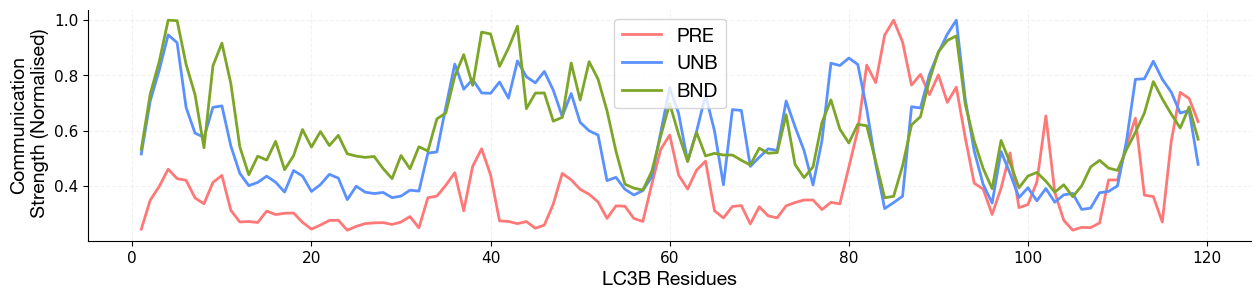

In [8]:
font = {'family':'helvetica neue',
        'color':  'black',
        'weight': 'bold',
        'size': 14
        }
rs={'family':'helvetica neue',
    'size':14
   }

fig, ax = plt.subplots(figsize=(15, 3))


ax.plot(glob_comm_df["Residues"], glob_comm_df["PRE"]/max(glob_comm_df["PRE"]),
        color="#FF7878",lw=2,label="PRE")
#ax.scatter()
ax.plot(glob_comm_df["Residues"], glob_comm_df["UNB"]/max(glob_comm_df["UNB"]),
        color="#5A91FF",lw=2,label="UNB")
ax.plot(glob_comm_df["Residues"], glob_comm_df["BND"]/max(glob_comm_df["BND"]),
        color="#7DA629",lw=2,label="BND")


ax.tick_params(labelsize=11)
ax.set_xlabel('LC3B Residues', fontdict=font)  # Setting font for x-axis label
ax.set_ylabel('Communication\n Strength (Normalised)', fontdict=font)  # Setting font for y-axis label

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.1)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.1)

# ax.tick_params(labelsize=10)
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

# ax.set_ylim(0,1)
plt.legend(prop=rs)
plt.savefig('../../../plots/dihedrals/net_communication/comm_stren_normalised_all.png',transparent=True,
           dpi=450,bbox_inches='tight')

In [9]:
# For UNB (MEMBRANE-BOUND STATE)

In [10]:
def glob_comm_ret(res_ls, state):
    
    glob_comm_ls=[]
    for i in res_ls:
        val=glob_comm_df.iloc[i-1]
        glob_comm_ls.append(val[state]/max(glob_comm_df[state]))
    
    return glob_comm_ls

In [11]:
MTM_all=[1,2,3,4,5,6,7,8,9,10,12,36,37,38,39,40,41,42,43,44,46,80,82,84,85,112,114,115,116,117,118,119] 
MTM_core=[1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 37, 38, 39, 40, 41, 42, 43, 45, 46, 119]
# MTM_vicinity=[i for i in MTM_all if i not in MTM_core]
# MTM_vicinity=[7,8,13,16,36,44,47,111,115,118]
MTM_vicinity=[7,8,44,]
# triad_res=[59,60,61,64,68]+[i for i in range(71,80)]+[i for i in range(83,93)]
# triad_neigh_res=[58,62,63,65,67,69,70,80,81,82,93,94]
triad_neigh_res=[62,65,69,80,81,82,93,94]
triad_res=[59,60,61,64,68]+[i for i in range(71,80)]+[i for i in range(83,93)]+triad_neigh_res

Triad_H3=[59,60,61,64,68]
Triad_L5=[i for i in range(71,80)]
Triad_L6=[i for i in range(83,93)]
hp_1=[19,23,32,34,51,53,108]
hp_2=[35,52,54,55,58,63,66,67,70]
pock=hp_1+hp_2

others=[i for i in range(1,120) if i not in MTM_all+triad_res+pock+triad_neigh_res+MTM_vicinity]

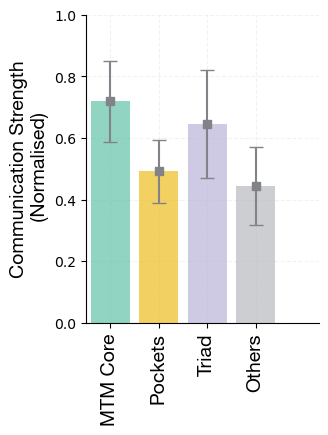

In [12]:
import matplotlib.pyplot as plt
import numpy as np

#  data
groups = ['MTM Core', 'Pockets', 'Triad', 'Others']
x = np.arange(len(groups))  # numerical x-axis positions

# pre_means = [np.mean(i) for i in ]
# pre_errors = [np.std(i) for i in ]


unb_means = [np.mean(i) for i in (glob_comm_ret(MTM_core,'UNB'),
                                 glob_comm_ret(pock,'UNB'),
                                 glob_comm_ret(triad_res,'UNB'),
                                #glob_comm_ret(triad_neigh_res,'UNB'),
                                 glob_comm_ret(others,'UNB'))]
unb_errors = [np.std(i) for i in (glob_comm_ret(MTM_core,'UNB'),
                                 glob_comm_ret(pock,'UNB'),
                                  #glob_comm_ret(triad_neigh_res,'UNB'),
                                 glob_comm_ret(triad_res,'UNB'),
                                 glob_comm_ret(others,'UNB'))]

col_ls=['#63C2A7','#EDBE1F','#BAB4D8','#B8BAC0' ]

fig, ax = plt.subplots(figsize=(3, 4))

ax.bar(x, unb_means, color=col_ls, alpha=0.7)

ax.errorbar(x , unb_means, yerr=unb_errors, fmt='s', 
             capsize=5, label='Apo Membrane-bound', color='#818388')

ax.set_xticks(x, groups, rotation=90)
ax.set_xticklabels(groups,fontdict=font)

ax.set_ylabel('Communication Strength\n (Normalised)', fontdict=font)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)

ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.1)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.1)



ax.set_xlim(-0.5,4.3)
ax.set_ylim(0,1)


plt.savefig('../../../plots/dihedrals/net_communication/UNB_region_wise_comm_stren.png',
            dpi=450,transparent=True,
               bbox_inches='tight')

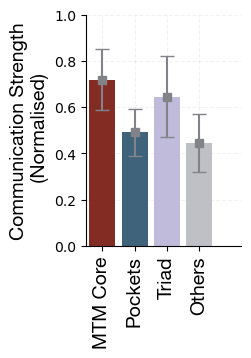

In [13]:
import matplotlib.pyplot as plt
import numpy as np

#  data
groups = ['MTM Core', 'Pockets', 'Triad', 'Others']
x = np.arange(len(groups))  # numerical x-axis positions

# pre_means = [np.mean(i) for i in ]
# pre_errors = [np.std(i) for i in ]


unb_means = [np.mean(i) for i in (glob_comm_ret(MTM_core,'UNB'),
                                 glob_comm_ret(pock,'UNB'),
                                 glob_comm_ret(triad_res,'UNB'),
                                #glob_comm_ret(triad_neigh_res,'UNB'),
                                 glob_comm_ret(others,'UNB'))]
unb_errors = [np.std(i) for i in (glob_comm_ret(MTM_core,'UNB'),
                                 glob_comm_ret(pock,'UNB'),
                                  #glob_comm_ret(triad_neigh_res,'UNB'),
                                 glob_comm_ret(triad_res,'UNB'),
                                 glob_comm_ret(others,'UNB'))]

col_ls=["#76150C","#29526D",'#BAB4D8','#B8BAC0' ]

fig, ax = plt.subplots(figsize=(2, 3))

ax.bar(x, unb_means, color=col_ls, alpha=0.9)

ax.errorbar(x , unb_means, yerr=unb_errors, fmt='s', 
             capsize=5, label='Apo Membrane-bound', color='#818388')

ax.set_xticks(x, groups, rotation=90)
ax.set_xticklabels(groups,fontdict=font)

ax.set_ylabel('Communication Strength\n (Normalised)', fontdict=font)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)

ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.1)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.1)



ax.set_xlim(-0.5,4.3)
ax.set_ylim(0,1)


plt.savefig('../../../plots/dihedrals/net_communication/UNB_region_wise_comm_stren_modified.png',
            dpi=450,transparent=True,
               bbox_inches='tight')

In [15]:
unb_comm_stren_region_wise=pd.DataFrame()
unb_comm_stren_region_wise["Residues"]=MTM_core+pock+triad_res+others
unb_comm_stren_region_wise["Region"]=["MTM" for i in MTM_core]+["BP" for i in pock]+["Triad" for i in triad_res]+\
["Others" for i in others]
unb_comm_stren_region_wise["Communication strength (Normalised)"]=glob_comm_ret(MTM_core,'UNB')+glob_comm_ret(pock,'UNB')+\
glob_comm_ret(triad_res,'UNB')+glob_comm_ret(others,'UNB')
unb_comm_stren_region_wise.to_csv("../../../../LC3_paper_data_files_for_source_data_comp/comm_stren_unb_region_wise.csv")

In [11]:
glob_comm_seg=[glob_comm_ret(MTM_core,'UNB'),
 glob_comm_ret(pock,'UNB'),
 glob_comm_ret(triad_res,'UNB'),
 glob_comm_ret(triad_neigh_res,'UNB'),
 glob_comm_ret(others,'UNB')]

col_ls=['#63C2A7','#EDBE1F','#BAB4D8','#BACAEB','#B8BAC0' ]


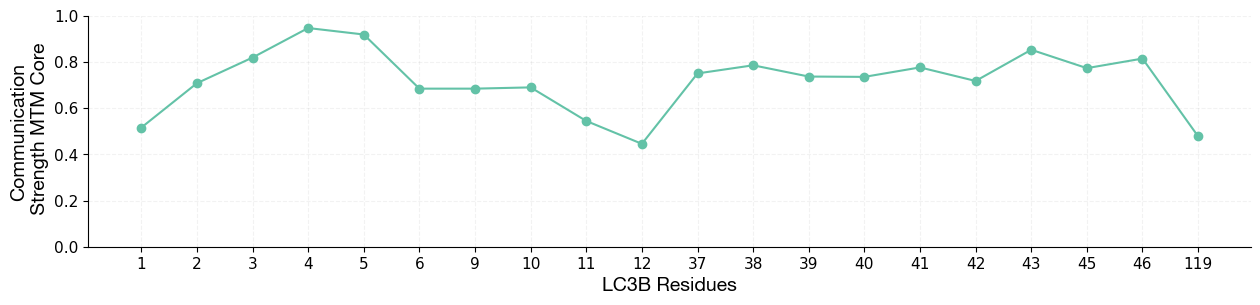

In [12]:
font = {'family':'helvetica neue',
        'color':  'black',
        'weight': 'bold',
        'size': 14
        }
rs={'family':'helvetica neue',
    'size':14
   }

fig, ax = plt.subplots(figsize=(15, 3))


ax.plot([str (i) for i in MTM_core], glob_comm_seg[0],color=col_ls[0])
ax.scatter([str (i) for i in MTM_core], glob_comm_seg[0],color=col_ls[0])


ax.tick_params(labelsize=11)
ax.set_xlabel('LC3B Residues', fontdict=font)  # Setting font for x-axis label
ax.set_ylabel('Communication\n Strength MTM Core', fontdict=font)  # Setting font for y-axis label

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.1)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.1)

# ax.tick_params(labelsize=10)
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

ax.set_ylim(0,1)
# plt.legend(prop=rs)
plt.savefig('../../../plots/dihedrals/net_communication/UNB_MTM_CORE_comm_stren.png',transparent=True,
           dpi=450,bbox_inches='tight')

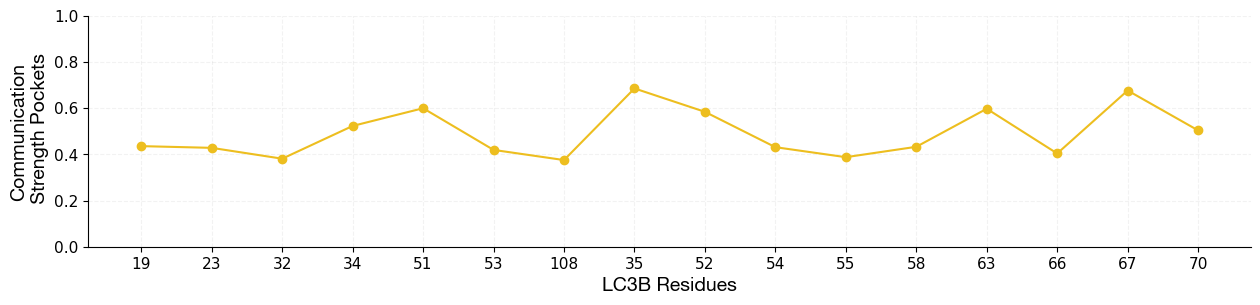

In [13]:
font = {'family':'helvetica neue',
        'color':  'black',
        'weight': 'bold',
        'size': 14
        }
rs={'family':'helvetica neue',
    'size':14
   }

fig, ax = plt.subplots(figsize=(15, 3))


ax.plot([str (i) for i in pock], glob_comm_seg[1],color=col_ls[1])
ax.scatter([str (i) for i in pock], glob_comm_seg[1],color=col_ls[1])


ax.tick_params(labelsize=11)
ax.set_xlabel('LC3B Residues', fontdict=font)  # Setting font for x-axis label
ax.set_ylabel('Communication\n Strength Pockets', fontdict=font)  # Setting font for y-axis label

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.1)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.1)

# ax.tick_params(labelsize=10)
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

ax.set_ylim(0,1)
# plt.legend(prop=rs)
plt.savefig('../../../plots/dihedrals/net_communication/UNB_BP_CORE_comm_stren.png',transparent=True,
           dpi=450,bbox_inches='tight')

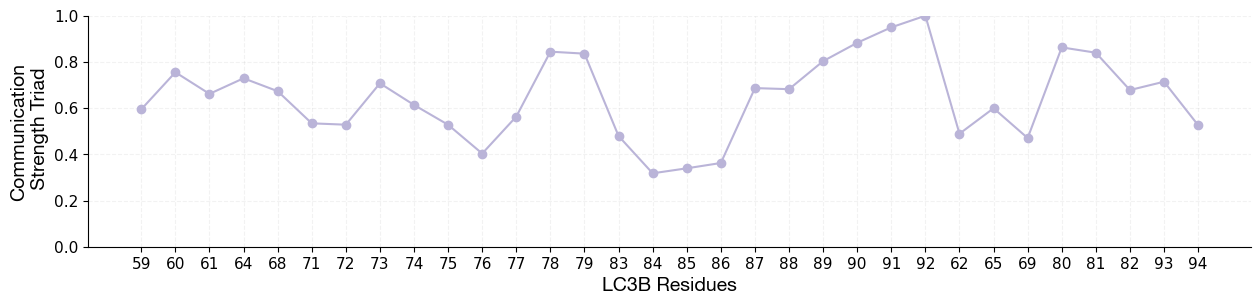

In [14]:
font = {'family':'helvetica neue',
        'color':  'black',
        'weight': 'bold',
        'size': 14
        }
rs={'family':'helvetica neue',
    'size':14
   }

fig, ax = plt.subplots(figsize=(15, 3))


ax.plot([str (i) for i in triad_res], glob_comm_seg[2],color=col_ls[2])
ax.scatter([str (i) for i in triad_res], glob_comm_seg[2],color=col_ls[2])


ax.tick_params(labelsize=11)
ax.set_xlabel('LC3B Residues', fontdict=font)  # Setting font for x-axis label
ax.set_ylabel('Communication\n Strength Triad', fontdict=font)  # Setting font for y-axis label

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.1)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.1)

# ax.tick_params(labelsize=10)
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

ax.set_ylim(0,1)
# plt.legend(prop=rs)
plt.savefig('../../../plots/dihedrals/net_communication/UNB_TRIAD_CORE_comm_stren.png',transparent=True,
           dpi=450,bbox_inches='tight')

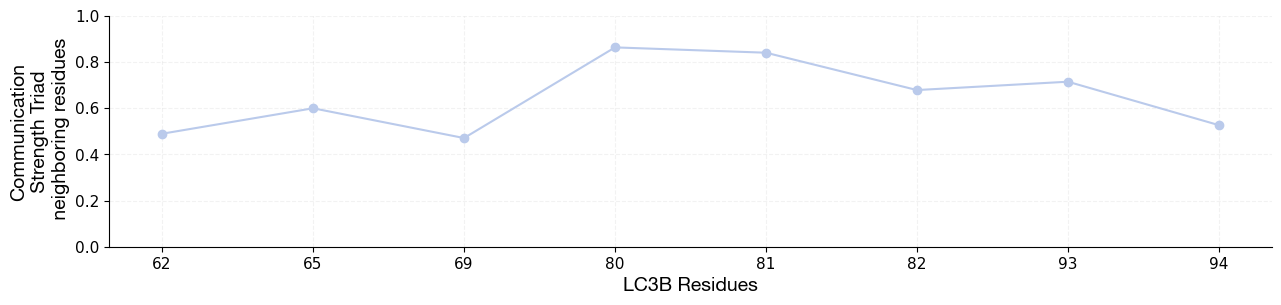

In [15]:
font = {'family':'helvetica neue',
        'color':  'black',
        'weight': 'bold',
        'size': 14
        }
rs={'family':'helvetica neue',
    'size':14
   }

fig, ax = plt.subplots(figsize=(15, 3))


ax.plot([str (i) for i in triad_neigh_res], glob_comm_seg[3],color=col_ls[3])
ax.scatter([str (i) for i in triad_neigh_res], glob_comm_seg[3],color=col_ls[3])


ax.tick_params(labelsize=11)
ax.set_xlabel('LC3B Residues', fontdict=font)  # Setting font for x-axis label
ax.set_ylabel('Communication\n Strength Triad \n neighboring residues', fontdict=font)  # Setting font for y-axis label

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.1)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.1)

# ax.tick_params(labelsize=10)
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

ax.set_ylim(0,1)
# plt.legend(prop=rs)
plt.savefig('../../../plots/dihedrals/net_communication/UNB_TRIAD_NEIGH_comm_stren.png',transparent=True,
           dpi=450,bbox_inches='tight')

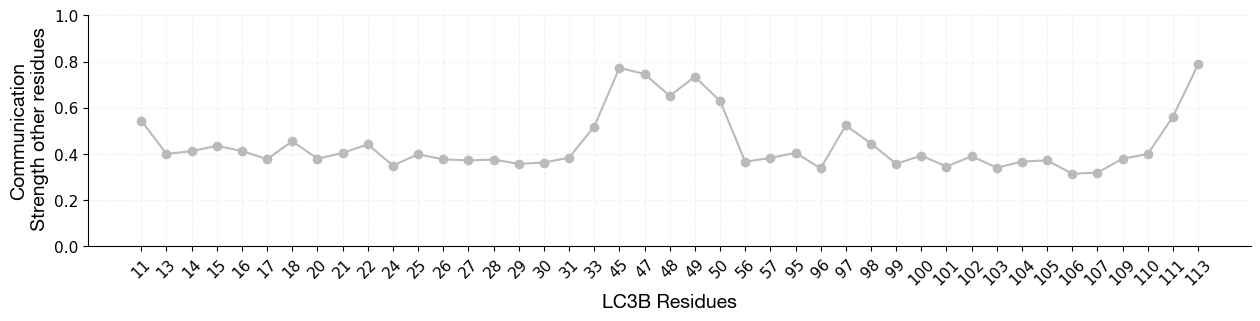

In [16]:
font = {'family':'helvetica neue',
        'color':  'black',
        'weight': 'bold',
        'size': 14
        }
rs={'family':'helvetica neue',
    'size':14
   }

fig, ax = plt.subplots(figsize=(15, 3))


ax.plot([str (i) for i in others], glob_comm_seg[4],color=col_ls[4])
ax.scatter([str (i) for i in others], glob_comm_seg[4],color=col_ls[4])


ax.tick_params(labelsize=11)
ax.set_xlabel('LC3B Residues', fontdict=font)  # Setting font for x-axis label
ax.set_ylabel('Communication\n Strength other residues', fontdict=font)  # Setting font for y-axis label

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.1)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.1)

# ax.tick_params(labelsize=10)
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

ax.set_ylim(0,1)
ax.set_xticks([i for i in range(len(others))], [str (i) for i in others],rotation=45)
# plt.legend(prop=rs)
plt.savefig('../../../plots/dihedrals/net_communication/UNB_REST_comm_stren.png',transparent=True,
           dpi=450,bbox_inches='tight')

In [26]:
pwd

'/Volumes/Seagate Hub/LC3_conformations_scripts_data/scripts/dihedrals/net_communication'